# Load a tabular data set

In [15]:
!pip install matplotlib
!pip install pandas
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)


In [2]:

# Issues with packages turicreate running in Mac platform
"""  import turicreate
sf = turicreate.SFrame('people-example.csv')"""

#Instead we will other ways to analysis the data
import pandas as pd
df = pd.read_csv('people-example.csv')

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# DataFrame basics

In [4]:
df #we can view first few lines of table
df.head()
df.tail()  # view end of the table

,First Name,Last Name,Country,age
2,Malcolm,Jone,England,22
3,Felix,Brown,USA,23
4,Alex,Cooper,Poland,23
5,Tod,Campbell,United States,22
6,Derek,Ward,Switzerland,25


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   First Name  7 non-null      object
 1   Last Name   7 non-null      object
 2   Country     7 non-null      object
 3   age         7 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 352.0+ bytes


,age
count,7.000000
mean,23.142857
std,1.069045
min,22.000000
25%,22.500000
50%,23.000000
75%,23.500000
max,25.000000


# Create visualization

7
count     7.000000
mean     23.142857
std       1.069045
min      22.000000
25%      22.500000
50%      23.000000
75%      23.500000
max      25.000000
Name: age, dtype: float64


<Axes: title={'center': 'Age Distribution'}, ylabel='Frequency'>

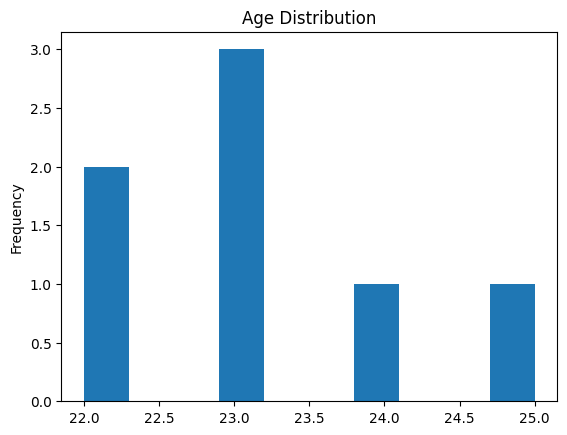

In [6]:
print(df['age'].count())
print(df['age'].describe())
df['age'].plot(kind='hist', bins=10, title='Age Distribution')

# Inspect columns of dataset

In [7]:
df['Country']

0    United States
1           Canada
2          England
3              USA
4           Poland
5    United States
6      Switzerland
Name: Country, dtype: object

In [8]:
df['age']

0    24
1    23
2    22
3    23
4    23
5    22
6    25
Name: age, dtype: int64

Some simple columnar operations

In [9]:
df['age'].mean()

23.142857142857142

In [10]:
df['age'].max()

25

# Create new columns

In [11]:
df['Full Name'] = df['First Name'] + ' ' + df['Last Name']

In [12]:
df['age'] * df['age']



0    576
1    529
2    484
3    529
4    529
5    484
6    625
Name: age, dtype: int64

# Use the apply function to do a advance transformation of our data

In [13]:
df['Country']

0    United States
1           Canada
2          England
3              USA
4           Poland
5    United States
6      Switzerland
Name: Country, dtype: object

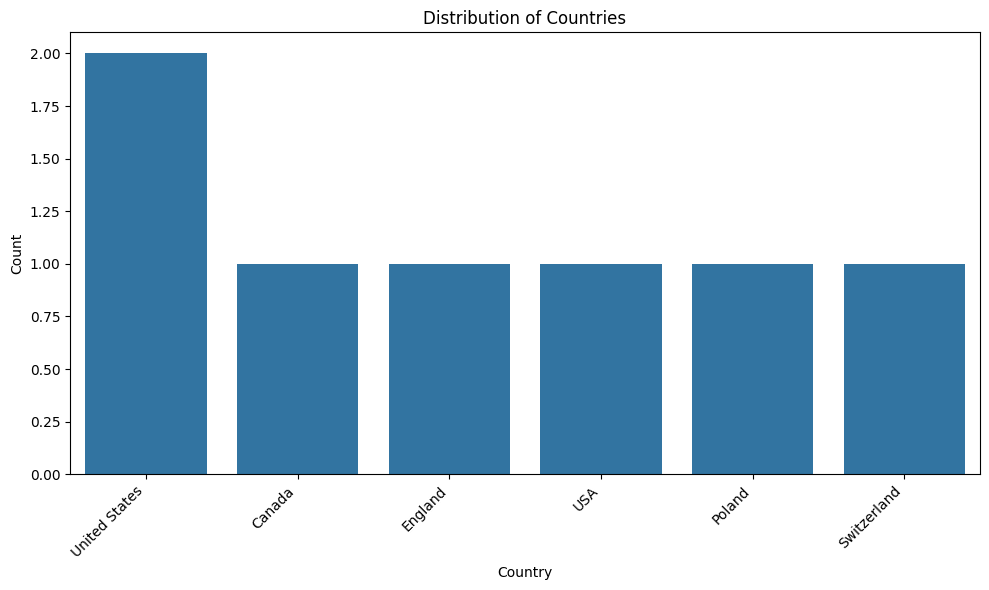

In [17]:
country_counts = df['Country'].value_counts()

# Create the plot
plt.figure(figsize=(10, 6))  # Adjust figure size for better readability
sns.countplot(x='Country', data=df, order=country_counts.index)
plt.title('Distribution of Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()


In [18]:
def transform_country(country):
    if country == 'USA':
        return 'United States'
    else:
        return country

In [19]:
transform_country('Brazil')

'Brazil'

In [20]:
transform_country('Brasil')

'Brasil'

In [21]:
transform_country('USA')

'United States'

In [22]:
df['Country'].apply(transform_country)

0    United States
1           Canada
2          England
3    United States
4           Poland
5    United States
6      Switzerland
Name: Country, dtype: object

In [23]:
df['Country'] = df['Country'].apply(transform_country)

In [24]:
df

,First Name,Last Name,Country,age,Full Name
0,Bob,Smith,United States,24,Bob Smith
1,Alice,Williams,Canada,23,Alice Williams
2,Malcolm,Jone,England,22,Malcolm Jone
3,Felix,Brown,United States,23,Felix Brown
4,Alex,Cooper,Poland,23,Alex Cooper
5,Tod,Campbell,United States,22,Tod Campbell
6,Derek,Ward,Switzerland,25,Derek Ward
